In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.layers import Multiply

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_DIR = "/content/drive/MyDrive/final_project/dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
EPOCHS = 25
NUM_CLASSES = 3

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4800 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


In [6]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
x = base_model.output

# Global pooling
x = GlobalAveragePooling2D()(x)

# 🔥 Attention Mechanism
attention = Dense(1536, activation='sigmoid')(x)
x = Multiply()([x, attention])

# Fully connected layers
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

hybrid_model = Model(inputs=base_model.input, outputs=output)

In [11]:
hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 13,538,610 (51.65 MB)

 Trainable params: 2,755,075 (10.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 4626s 15s/step - accuracy: 0.5292 - loss: 0.9612 - val_accuracy: 0.5617 - val_loss: 0.8983
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 186s 621ms/step - accuracy: 0.6052 - loss: 0.8514 - val_accuracy: 0.6067 - val_loss: 0.8468
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 180s 600ms/step - accuracy: 0.6235 - loss: 0.8098 - val_accuracy: 0.6167 - val_loss: 0.8108
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 182s 608ms/step - accuracy: 0.6444 - loss: 0.7765 - val_accuracy: 0.6200 - val_loss: 0.7900
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 183s 611ms/step - accuracy: 0.6644 - loss: 0.7506 - val_accuracy: 0.6450 - val_loss: 0.7758
Epoch 6/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 179s 597ms/step - accuracy: 0.6719 - loss: 0.7433 - val_accuracy: 0.6417 - val_loss: 0.7690
Epoch 7/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 180s 599ms/step - accuracy: 0.6733 - loss: 0.7293 - val_accuracy: 0.6567 - val_loss: 0.7540
Epoch 8/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 178s 594ms/step - accuracy: 0.6892 - 

In [14]:
test_loss, test_acc = hybrid_model.evaluate(test_generator)

print("Hybrid Model Test Accuracy:", test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 494s 13s/step - accuracy: 0.6800 - loss: 0.6986
Hybrid Model Test Accuracy: 0.6800000071525574


In [15]:
# Unfreeze last layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 251s 668ms/step - accuracy: 0.6440 - loss: 0.7869 - val_accuracy: 0.6583 - val_loss: 0.7372
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 179s 598ms/step - accuracy: 0.6779 - loss: 0.7349 - val_accuracy: 0.6650 - val_loss: 0.7234
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 189s 630ms/step - accuracy: 0.6902 - loss: 0.6971 - val_accuracy: 0.6733 - val_loss: 0.7134
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 188s 625ms/step - accuracy: 0.7123 - loss: 0.6627 - val_accuracy: 0.6750 - val_loss: 0.6990
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 190s 632ms/step - accuracy: 0.7231 - loss: 0.6465 - val_accuracy: 0.6800 - val_loss: 0.6973
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 188s 625ms/step - accuracy: 0.7237 - loss: 0.6334 - val_accuracy: 0.6850 - val_loss: 0.6868
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 185s 616ms/step - accuracy: 0.7329 - loss: 0.6253 - val_accuracy: 0.6867 - val_loss: 0.6802
Epoch 8/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 185s 617ms/step - accuracy: 0.7350 -

In [16]:
test_loss, test_acc = hybrid_model.evaluate(test_generator)

print("Hybrid Model Test Accuracy:", test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.7283 - loss: 0.6102
Hybrid Model Test Accuracy: 0.7283333539962769


In [17]:
hybrid_model.save("/content/drive/MyDrive/final_project/hybrid_model.h5")
hybrid_model.save("/content/drive/MyDrive/final_project/hybrid_model.keras")

**Accuracy Curve**

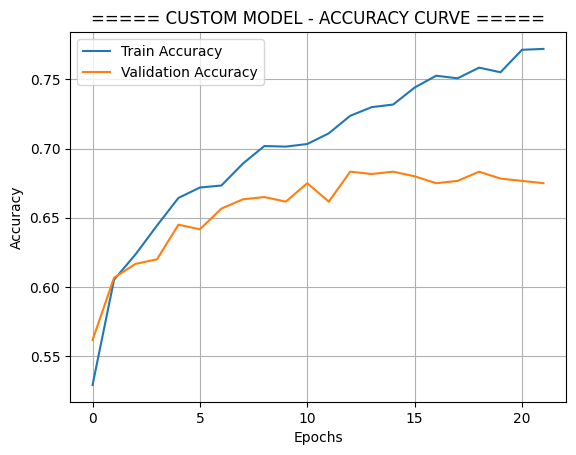

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("===== CUSTOM MODEL - ACCURACY CURVE =====")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

**Loss Curve**

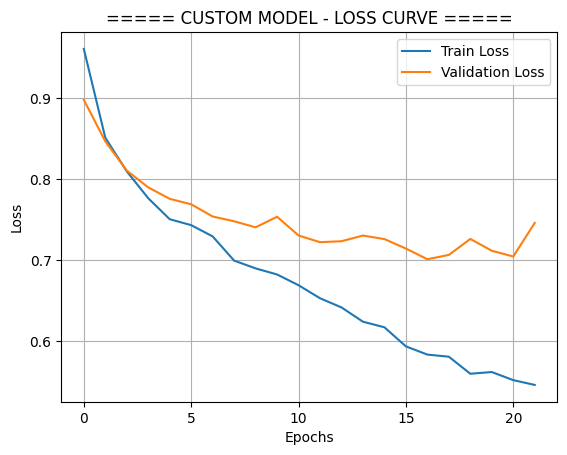

In [19]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("===== CUSTOM MODEL - LOSS CURVE =====")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

**Confusion Matrix**

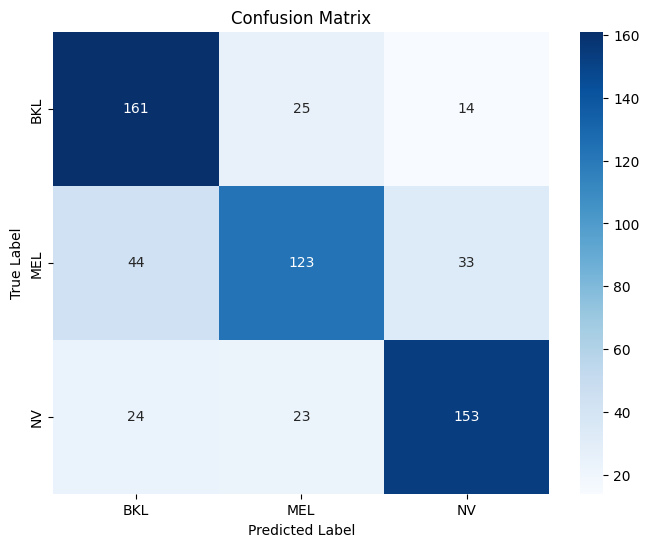

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Metrices Table**

In [24]:
from sklearn.metrics import classification_report, accuracy_score

report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

print("\n====== CUSTOM MODEL - METRICS TABLE ======\n")

print("{:<8} {:<10} {:<10} {:<10} {:<12} {:<10} {:<10}".format(
    "Class", "Precision", "Recall", "F1-Score", "Specificity", "IoU", "Dice"
))

specificity_list = []
iou_list = []

for i, cls in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = report[cls]['precision']
    recall = report[cls]['recall']
    f1 = report[cls]['f1-score']

    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    dice = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) != 0 else 0

    specificity_list.append(specificity)
    iou_list.append(iou)

    print("{:<8} {:<10.6f} {:<10.6f} {:<10.6f} {:<12.6f} {:<10.6f} {:<10.6f}".format(
        cls, precision, recall, f1, specificity, iou, dice
    ))

overall_accuracy = accuracy_score(y_true, y_pred)
mean_iou = np.mean(iou_list)

print("\nCustom Model Accuracy: {:.4f}".format(overall_accuracy))
print("Custom Model Mean IoU: {:.4f}".format(mean_iou))


====== CUSTOM MODEL - METRICS TABLE ======

Class    Precision  Recall     F1-Score   Specificity  IoU        Dice      
BKL      0.703057   0.805000   0.750583   0.830000     0.600746   0.750583  
MEL      0.719298   0.615000   0.663073   0.880000     0.495968   0.663073  
NV       0.765000   0.765000   0.765000   0.882500     0.619433   0.765000  

Custom Model Accuracy: 0.7283
Custom Model Mean IoU: 0.5720


**ROC Curve**

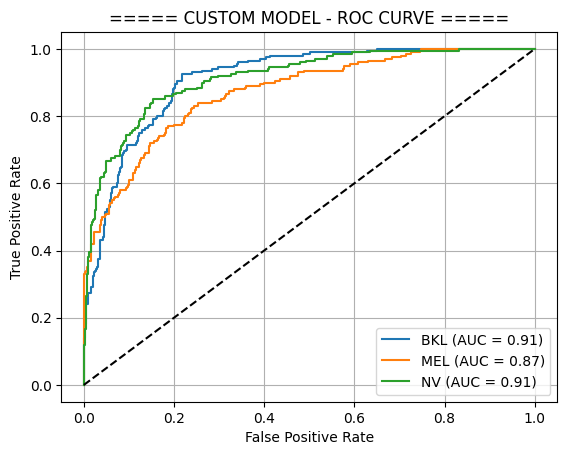

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

num_classes = len(class_names)
y_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure()

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.title("===== CUSTOM MODEL - ROC CURVE =====")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()